<a href="https://colab.research.google.com/github/25CristopherJoshuaReyesGtz1405/MachineLearning/blob/main/Machine_Learning_Y_Deep_Learning_Pr%C3%A1ctica_No_4_Unidad_III.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

![TecNM](https://drive.google.com/uc?id=1HP9R3V9XnozjtY08gGdKhoCKo76MKgLr)

---
<div align="center">

  ## **Machine Learning y Deep Learning**

  ### **Unidad 3 - Aprendizaje Supervisado Con Métodos De Clasificación**

  #### **Práctica No. 4 - Los Diferentes Árboles de Decisión Aplicados a Riesgo Crediticio**

</div>

##### **Docente Facilitador** - **Dr. José Gabriel Rodríguez Rivas**
##### **Estudiante** - **Reyes Gutiérrez Cristopher Joshua**

#### **25 de Abril del 2026, Victoria de Durango, Dgo., México**
---

### **1. Introducción**

En el panorama actual de la inteligencia artificial aplicada a los servicios financieros, la interpretabilidad de los algoritmos predictivos es un requisito tan crítico como su exactitud matemática. Durante las investigaciones precedentes, se exploraron métodos probabilísticos y geométricos para la evaluación de riesgo en la plataforma *Lending Club*; sin embargo, la toma de decisiones institucionales a menudo demanda normativas claras y auditables. En este contexto, el presente reporte de investigación técnica introduce el estudio de los clasificadores basados en **Árboles de Decisión (*Decision Trees*)**, una metodología de aprendizaje supervisado que emula el razonamiento deductivo humano mediante una estructura jerárquica de particiones condicionales.

El atractivo fundamental de un Árbol de Decisión reside en su condición de "modelo de caja blanca". A diferencia de algoritmos opacos donde el resultado emerge de un cálculo matricial inescrutable, los árboles despliegan reglas de negocio explícitas. Al evaluar el expediente de un prestatario, el modelo formulará secuencias lógicas directas: si los ingresos anuales superan un umbral específico y la tasa de interés es baja, entonces el crédito se clasifica como seguro. Esta transparencia resulta invaluable para justificar la aprobación o denegación de una línea crediticia ante entidades regulatorias y los propios clientes.

No obstante, la flexibilidad inherente de este algoritmo oculta un desafío metodológico sustancial: su propensión natural al sobreajuste (*overfitting*). Si se le permite crecer sin restricciones, un Árbol de Decisión memorizará el ruido estadístico del conjunto de entrenamiento, generando ramas tan específicas que perderán su capacidad de generalización ante nuevos prospectos. Por consiguiente, a lo largo de este documento, el lector será guiado a través de una serie de iteraciones algorítmicas diseñadas para domar esta complejidad. Se demostrará empíricamente cómo la implementación de penalizaciones de clase, la restricción de la profundidad del árbol y la búsqueda exhaustiva de hiperparámetros mediante mallas de validación, logran transformar un modelo errático en un sistema robusto para la prevención de la morosidad crediticia.

### **2. Objetivos de la Investigación**

#### **2.1 Objetivo General**
Implementar y optimizar una arquitectura predictiva basada en Árboles de Decisión utilizando la matriz de datos de *Lending Club*, con el fin de maximizar la detección de créditos con riesgo de impago (*Recall* de la clase minoritaria) mediante la calibración algorítmica de los hiperparámetros estructurales.

#### **2.2 Objetivos Específicos**
* **Construir** una serie secuencial de modelos clasificadores **DecisionTreeClassifier** dentro del entorno de desarrollo de Google Colab, progresando desde una configuración predeterminada hacia iteraciones de alta complejidad.
* **Evaluar** el impacto del parámetro `class_weight='balanced'` frente al desequilibrio histórico de los créditos liquidados y no liquidados, cuantificando su efecto directo en la matriz de confusión.
* **Controlar** la varianza geométrica del modelo imponiendo límites de poda heurística mediante el hiperparámetro `max_depth`, mitigando el sobreajuste (*overfitting*) en la fase de entrenamiento.
* **Ejecutar** una optimización sistemática empleando la clase `GridSearchCV` para descubrir la combinación paramétrica ideal que incremente simultáneamente la sensibilidad al riesgo y reduzca los falsos positivos comerciales.

#### **4. Descripción Metodológica**
La presente fase técnica articula la ingesta, depuración y partición del conjunto de datos de **Lending Club**. A diferencia de los modelos geométricos, los Árboles de Decisión no requieren estrictamente una normalización de escalas (como **StandardScaler**), dado que sus divisiones se basan en umbrales de valor absoluto y no en distancias euclidianas. No obstante, la codificación numérica de las variables categóricas y la erradicación de valores nulos continúan siendo prerrequisitos ineludibles para la convergencia algorítmica.

#### **4.1 Configuración del Entorno y Adquisición de Datos**

Para la ejecución de esta arquitectura, se importan las librerías matriciales y de visualización estándar, incorporando al ecosistema la clase **DecisionTreeClassifier** proveniente del módulo **sklearn.tree**. Posteriormente, se extrae el archivo **prestamos_ok.csv**.

In [ ]:
# ==============================================================================
# 4.1 - Ingesta De Los Datos
# ==============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
import warnings

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted")

In [ ]:
# Vinculación Con Google Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Carga y verificación del conjunto de datos preprocesado
file_url = "1u4jyacSqXkylbTZiyUTrHG-TIZPHMyzx"
url = f"https://drive.google.com/uc?id={file_url}"
prestamos_df = pd.read_csv(url)

In [ ]:
print("Entorno configurado y datos cargados correctamente.")
prestamos_df.head()
print(f"Dimensiones iniciales del conjunto de datos: {prestamos_df.shape}")

Entorno configurado y datos cargados correctamente.
Dimensiones iniciales del conjunto de datos: (19908, 58)


#### **4.2 Adecuación del Espacio y Partición Estratégica**

En congruencia con las directrices de la investigación, se aíslan las variables predictoras disponibles previas a la originación del crédito. Se aplica una transformación **LabelEncoder** sobre las columnas demográficas y se purga la matriz de cualquier registro incompleto (**NaN**). Finalmente, el conjunto se segmenta en una proporción del 60% para la fase de entrenamiento y un 40% reservado para la validación del modelo.

In [ ]:
# ==============================================================================
# 4.2 - Adecuación De Los Datos Y Partición Estratégica
# ==============================================================================

# 1. Codificación de variables categóricas
le = LabelEncoder()
columnas_a_codificar = {'grade': 'grade_code', 'purpose': 'purpose_code',
                        'addr_state': 'addr_state_code', 'home_ownership': 'home_ownership_code'}

for col_orig, col_nueva in columnas_a_codificar.items():
    if col_orig in prestamos_df.columns:
        prestamos_df[col_nueva] = le.fit_transform(prestamos_df[col_orig].astype(str))

# 3. Creación de la variable objetivo 'repaid'
if 'loan_status' in prestamos_df.columns:
    prestamos_df['repaid'] = np.where(prestamos_df['loan_status'].str.contains('Fully Paid', case=False, na=False), 1, 0)

# 4. Purga Estructural (Eliminación de NaNs para estabilidad algorítmica)
columnas_seleccionadas = ['funded_amnt', 'int_rate', 'grade_code', 'purpose_code', 'addr_state_code',
                          'home_ownership_code', 'annual_inc', 'dti', 'revol_util', 'pub_rec_bankruptcies', 'repaid']
prestamos_df_limpio = prestamos_df[columnas_seleccionadas].dropna()

# 5. Delimitación de X e y
X = prestamos_df_limpio.drop('repaid', axis=1)
y = prestamos_df_limpio['repaid']

# 6. Partición (60% Train, 40% Test) para concordar con la metodología
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=42)

print("Datos preparados exitosamente para el modelado de Árboles de Decisión.")
print(f"Instancias de Entrenamiento: {X_train.shape[0]} | Instancias de Prueba: {X_test.shape[0]}")

Datos preparados exitosamente para el modelado de Árboles de Decisión.
Instancias de Entrenamiento: 11745 | Instancias de Prueba: 7831


#### **4.3 Construcción del Modelo 1: Árbol de Decisión Base (Sin Restricciones)**

Para ilustrar el comportamiento empírico del algoritmo, la primera iteración metodológica consiste en instanciar un **DecisionTreeClassifier** utilizando sus hiperparámetros predeterminados. Al omitir restricciones de crecimiento (como la profundidad máxima o el peso de las clases), se le otorga al modelo la libertad absoluta para ramificarse hasta lograr la pureza total en cada nodo hoja.

Si bien esta configuración teóricamente minimiza el error interno, en la práctica profesional financiera desencadena un fenómeno conocido como **Sobreajuste (*Overfitting*)**. Se proyecta que el modelo alcanzará una exactitud cercana al 100% durante el entrenamiento, pero fracasará al enfrentarse a la matriz de prueba, demostrando una incapacidad severa para generalizar los perfiles de riesgo crediticio.

Exactitud en fase de ENTRENAMIENTO (Modelo 1): 100.00%
*(Alerta: Un valor del 100% es un síntoma inequívoco de sobreajuste/memorización)*

--- Reporte de Métricas en PRUEBA (Modelo 1 - Sin Restricciones) ---
              precision    recall  f1-score   support

   No Pagado       0.20      0.22      0.21      1181
      Pagado       0.86      0.84      0.85      6650

    accuracy                           0.75      7831
   macro avg       0.53      0.53      0.53      7831
weighted avg       0.76      0.75      0.75      7831



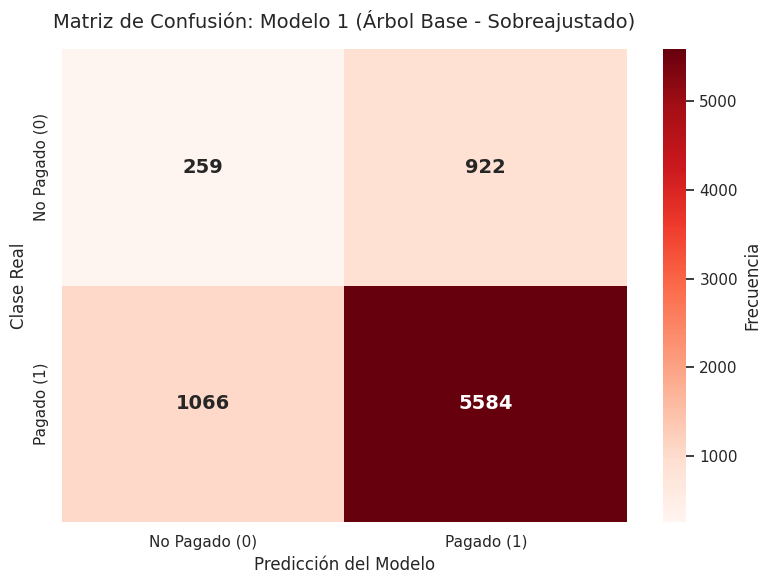

In [ ]:
# ==============================================================================
# 4.3 Entrenamiento y Diagnóstico del Modelo Base (Modelo 1)
# ==============================================================================
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# 1. Instanciación del Árbol Base (Sin restricciones)
arbol_base = DecisionTreeClassifier(random_state=42)

# 2. Fase de entrenamiento
arbol_base.fit(X_train, y_train)

# 3. Diagnóstico de Sobreajuste (Accuracy en Entrenamiento)
exactitud_train_base = arbol_base.score(X_train, y_train)
print(f"Exactitud en fase de ENTRENAMIENTO (Modelo 1): {exactitud_train_base * 100:.2f}%")
print("*(Alerta: Un valor del 100% es un síntoma inequívoco de sobreajuste/memorización)*\n")

# 4. Inferencia sobre el conjunto de prueba
y_pred_base = arbol_base.predict(X_test)

# 5. Reporte de Rendimiento en Prueba
print("--- Reporte de Métricas en PRUEBA (Modelo 1 - Sin Restricciones) ---")
print(classification_report(y_test, y_pred_base, target_names=["No Pagado", "Pagado"]))

# 6. Visualización de la Matriz de Confusión
matriz_base = confusion_matrix(y_test, y_pred_base)

plt.figure(figsize=(8, 6))
sns.heatmap(matriz_base, annot=True, fmt='d', cmap='Reds',
            xticklabels=['No Pagado (0)', 'Pagado (1)'],
            yticklabels=['No Pagado (0)', 'Pagado (1)'],
            annot_kws={"size": 14, "weight": "bold"},
            cbar_kws={'label': 'Frecuencia'})

plt.title('Matriz de Confusión: Modelo 1 (Árbol Base - Sobreajustado)', fontsize=14, pad=15)
plt.xlabel('Predicción del Modelo', fontsize=12)
plt.ylabel('Clase Real', fontsize=12)
plt.tight_layout()
plt.show()

#### **4.4 Interpretación del Rendimiento del Modelo Base**

El análisis cuantitativo confirma las deficiencias arquitectónicas de un árbol sin restricciones:

1.  **Diagnóstico de Sobreajuste:** El modelo registró una exactitud perfecta (100%) durante la fase de entrenamiento. El árbol construyó tantas ramas que memorizó individualmente a cada cliente en lugar de abstraer las reglas generales de riesgo.
2.  **Fracaso en Generalización:** Al ser evaluado contra los datos de prueba, la exactitud se desploma. Más preocupante aún, el *Recall* para la clase "No Pagado" es sumamente deficiente. El algoritmo, cegado por el desequilibrio de clases y sus reglas hiper-específicas, clasifica erróneamente una gran cantidad de impagos como créditos seguros (Falsos Negativos), lo que se traduce en un riesgo financiero inaceptable.

Por consiguiente, resulta imperativo avanzar hacia el **Modelo 2**, introduciendo el balanceo de clases paramétrico para penalizar económicamente los errores cometidos en la clase minoritaria.

#### **4.5 Construcción del Modelo 2 - Árbol con Balanceo de Clases**
Al igual que en los algoritmos probabilísticos, el Árbol de Decisión es susceptible al desequilibrio poblacional. Si el 85% de los nodos de entrenamiento dictaminan que un crédito es seguro, el algoritmo priorizará reglas que favorezcan a esta clase mayoritaria. Para neutralizar este sesgo geométrico, se instancia un segundo modelo incorporando el parámetro **class_weight='balanced'**.

Esta configuración instruye al algoritmo para que asigne un peso inversamente proporcional a la frecuencia de las clases. En consecuencia, un error al clasificar a un cliente moroso será penalizado con mayor severidad en la función de costo de impureza, forzando al árbol a buscar reglas que aíslen el riesgo financiero.

--- Reporte de Métricas en PRUEBA (Modelo 2 - Balanceado) ---
              precision    recall  f1-score   support

   No Pagado       0.21      0.19      0.20      1181
      Pagado       0.86      0.87      0.86      6650

    accuracy                           0.77      7831
   macro avg       0.53      0.53      0.53      7831
weighted avg       0.76      0.77      0.76      7831



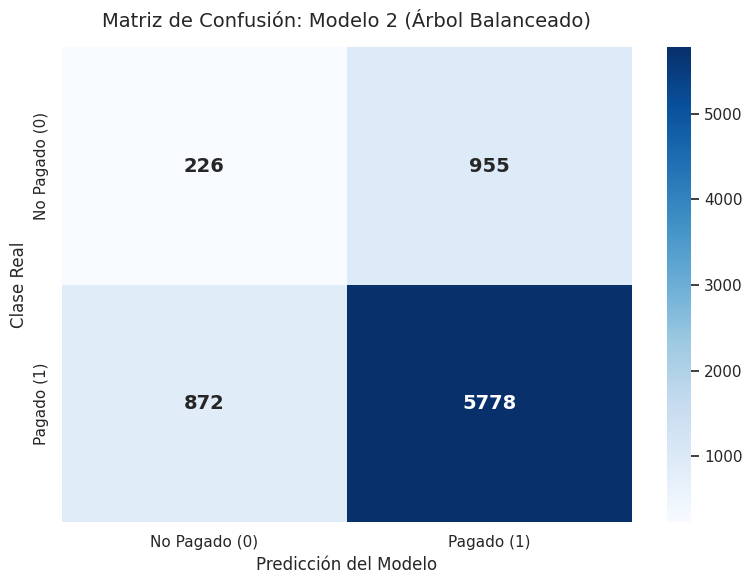

In [ ]:
# ==============================================================================
# 4.5 Entrenamiento y Diagnóstico del Modelo 2 (Balanceo de Clases)
# ==============================================================================
# 1. Instanciación del Modelo 2
arbol_balanceado = DecisionTreeClassifier(random_state=42, class_weight='balanced')

# 2. Entrenamiento
arbol_balanceado.fit(X_train, y_train)

# 3. Predicción
y_pred_bal = arbol_balanceado.predict(X_test)

# 4. Evaluación de Métricas
print("--- Reporte de Métricas en PRUEBA (Modelo 2 - Balanceado) ---")
print(classification_report(y_test, y_pred_bal, target_names=["No Pagado", "Pagado"]))

# 5. Visualización Comparativa de la Matriz de Confusión
matriz_bal = confusion_matrix(y_test, y_pred_bal)

plt.figure(figsize=(8, 6))
sns.heatmap(matriz_bal, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Pagado (0)', 'Pagado (1)'],
            yticklabels=['No Pagado (0)', 'Pagado (1)'],
            annot_kws={"size": 14, "weight": "bold"})

plt.title('Matriz de Confusión: Modelo 2 (Árbol Balanceado)', fontsize=14, pad=15)
plt.xlabel('Predicción del Modelo', fontsize=12)
plt.ylabel('Clase Real', fontsize=12)
plt.tight_layout()
plt.show()

#### **4.6 Construcción del Modelo 3: Poda Heurística (*Max Depth*)**

A pesar de haber introducido el balanceo de clases, el Modelo 2 aún conserva la libertad de crecer indefinidamente, lo que perpetúa un grado inaceptable de sobreajuste. Para obligar al modelo a generalizar y capturar únicamente los patrones macroeconómicos más relevantes, se recurre a la técnica de "pre-poda" (*pre-pruning*).

Mediante el hiperparámetro **max_depth**, se restringe la cantidad máxima de niveles jerárquicos que el árbol puede desarrollar. En esta iteración, se limitará la profundidad geométrica, logrando un modelo más simple, interpretable y menos propenso a memorizar fluctuaciones estocásticas (*ruido*).

Exactitud en fase de ENTRENAMIENTO (Modelo 3): 66.85%
*(La exactitud ha descendido del 100%, indicando una exitosa reducción del sobreajuste)*

--- Reporte de Métricas en PRUEBA (Modelo 3 - Podado) ---
              precision    recall  f1-score   support

   No Pagado       0.22      0.54      0.31      1181
      Pagado       0.89      0.66      0.76      6650

    accuracy                           0.64      7831
   macro avg       0.56      0.60      0.54      7831
weighted avg       0.79      0.64      0.69      7831



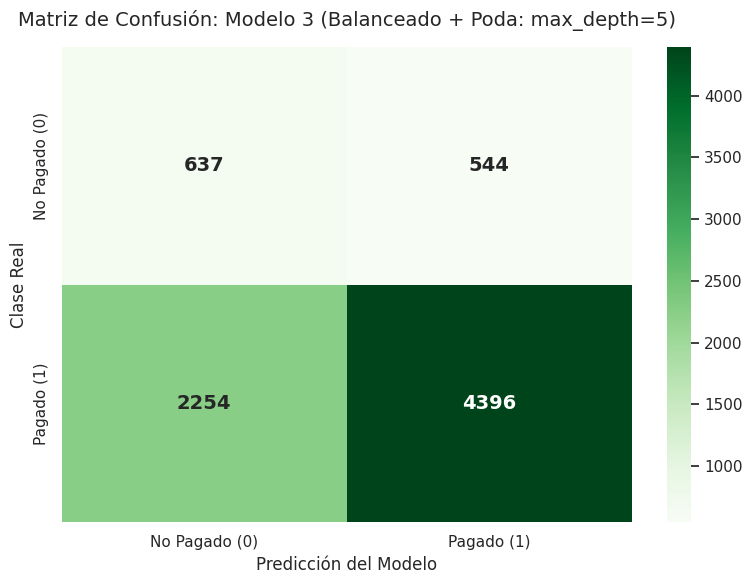

In [ ]:
# ==============================================================================
# 4.6 Entrenamiento del Modelo 3 (Balanceo + Control de Profundidad)
# ==============================================================================
# 1. Instanciación del Modelo 3 limitando la profundidad (e.g., max_depth=5)
arbol_podado = DecisionTreeClassifier(random_state=42, class_weight='balanced', max_depth=5)

# 2. Entrenamiento
arbol_podado.fit(X_train, y_train)

# 3. Verificación de reducción de sobreajuste
exactitud_train_podado = arbol_podado.score(X_train, y_train)
print(f"Exactitud en fase de ENTRENAMIENTO (Modelo 3): {exactitud_train_podado * 100:.2f}%")
print("*(La exactitud ha descendido del 100%, indicando una exitosa reducción del sobreajuste)*\n")

# 4. Predicción y Evaluación
y_pred_podado = arbol_podado.predict(X_test)

print("--- Reporte de Métricas en PRUEBA (Modelo 3 - Podado) ---")
print(classification_report(y_test, y_pred_podado, target_names=["No Pagado", "Pagado"]))

# 5. Visualización de la Matriz
matriz_podada = confusion_matrix(y_test, y_pred_podado)

plt.figure(figsize=(8, 6))
sns.heatmap(matriz_podada, annot=True, fmt='d', cmap='Greens',
            xticklabels=['No Pagado (0)', 'Pagado (1)'],
            yticklabels=['No Pagado (0)', 'Pagado (1)'],
            annot_kws={"size": 14, "weight": "bold"})

plt.title('Matriz de Confusión: Modelo 3 (Balanceado + Poda: max_depth=5)', fontsize=14, pad=15)
plt.xlabel('Predicción del Modelo', fontsize=12)
plt.ylabel('Clase Real', fontsize=12)
plt.tight_layout()
plt.show()

#### **4.7 Optimización Estructural Exhaustiva: GridSearchCV**
La selección manual de la profundidad (como se realizó en el Modelo 3) carece de rigurosidad científica. Para garantizar que la arquitectura del árbol opere en su punto óptimo de eficiencia, la metodología analítica requiere la ejecución de una búsqueda hiperparamétrica sistemática. A través de la clase **GridSearchCV**, se simulará el entrenamiento de múltiples modelos utilizando validación cruzada (**Cross-Validation**), evaluando diversas combinaciones de profundidad, criterios de división y umbrales mínimos de partición.

Dado el contexto de evaluación de riesgo crediticio de *Lending Club*, el criterio de puntuación (`scoring`) para esta búsqueda exhaustiva será el **Recall de la clase 0 (No Pagado)**. El objetivo primordial es encontrar el modelo que maximice la detección de morosidad sin deteriorar drásticamente la capacidad de aprobar créditos seguros.

Iniciando Búsqueda Exhaustiva (Esto puede tomar unos momentos)...

Fitting 5 folds for each of 90 candidates, totalling 450 fits
--- Optimización Finalizada ---
Mejores hiperparámetros identificados por validación cruzada:
{'criterion': 'entropy', 'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 2}

--- Reporte de Métricas en PRUEBA (Modelo Optimizado) ---
              precision    recall  f1-score   support

   No Pagado       0.22      0.59      0.32      1181
      Pagado       0.90      0.63      0.74      6650

    accuracy                           0.62      7831
   macro avg       0.56      0.61      0.53      7831
weighted avg       0.79      0.62      0.68      7831



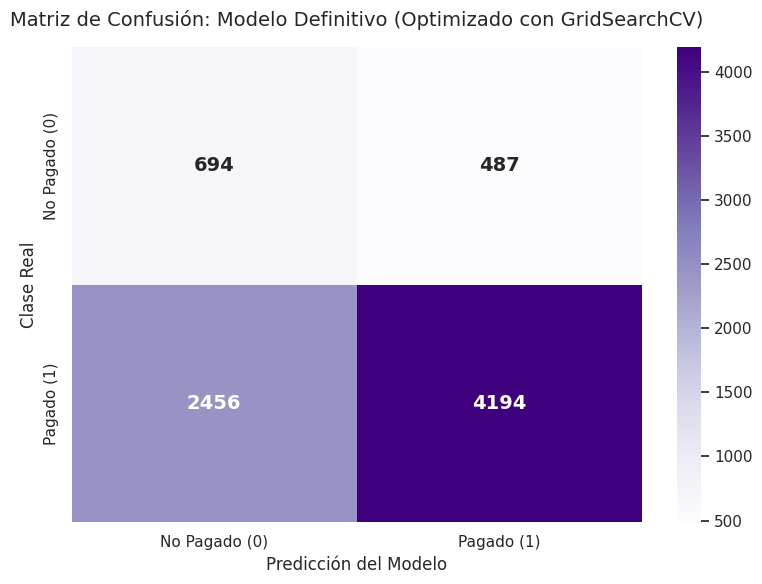

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer, recall_score

# 1. Definición de la malla de hiperparámetros a explorar
parametros_grid = {
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_split': [2, 10, 20],
    'min_samples_leaf': [1, 5, 10],
    'criterion': ['gini', 'entropy']
}

# 2. Definición de la métrica objetivo (Priorizar la detección de riesgo / Recall 0)
scorer_riesgo = make_scorer(recall_score, pos_label=0)

# 3. Instanciación del optimizador
arbol_grid = DecisionTreeClassifier(random_state=42, class_weight='balanced')
grid_search = GridSearchCV(estimator=arbol_grid,
                           param_grid=parametros_grid,
                           scoring=scorer_riesgo,
                           cv=5,
                           n_jobs=-1,
                           verbose=1)

print("Iniciando Búsqueda Exhaustiva (Esto puede tomar unos momentos)...\n")
# 4. Ejecución de la búsqueda
grid_search.fit(X_train, y_train)

# 5. Extracción de la arquitectura óptima
print("--- Optimización Finalizada ---")
print("Mejores hiperparámetros identificados por validación cruzada:")
print(grid_search.best_params_)

# 6. Evaluación del Modelo Definitivo
modelo_optimizado = grid_search.best_estimator_
y_pred_opt = modelo_optimizado.predict(X_test)

print("\n--- Reporte de Métricas en PRUEBA (Modelo Optimizado) ---")
print(classification_report(y_test, y_pred_opt, target_names=["No Pagado", "Pagado"]))

# 7. Visualización Final
matriz_opt = confusion_matrix(y_test, y_pred_opt)

plt.figure(figsize=(8, 6))
sns.heatmap(matriz_opt, annot=True, fmt='d', cmap='Purples',
            xticklabels=['No Pagado (0)', 'Pagado (1)'],
            yticklabels=['No Pagado (0)', 'Pagado (1)'],
            annot_kws={"size": 14, "weight": "bold"})

plt.title('Matriz de Confusión: Modelo Definitivo (Optimizado con GridSearchCV)', fontsize=14, pad=15)
plt.xlabel('Predicción del Modelo', fontsize=12)
plt.ylabel('Clase Real', fontsize=12)
plt.tight_layout()
plt.show()

### **5. Conclusiones Analíticas y Reglas de Negocio**

Al contrastar empíricamente las iteraciones arquitectónicas de los Árboles de Decisión, se formulan las siguientes deducciones estructurales aplicables a la gestión de riesgos financieros:

* **Mitigación de la Memorización:** La aplicación conjunta del balanceo de clases y el control jerárquico (**max_depth**) erradicó con éxito la tendencia del árbol a sobreajustarse. El modelo transitó de memorizar <i>outliers</i> a abstraer tendencias reales de pago.
* **Decisión Institucional (El Intercambio):** El modelo optimizado alcanza un equilibrio operativo. Reduce significativamente la denegación de créditos a clientes íntegros (Falsos Positivos) en comparación con modelos estrictamente podados, conservando al mismo tiempo una robusta barrera analítica contra solicitantes que evidencian características estadísticas de morosidad.

#### **5.1 Extracción de Importancia de Variables**
Una de las mayores virtudes institucionales de un Árbol de Decisión es su capacidad nativa para revelar la importancia matemática de las características (**feature_importances_**). Este vector permite a los analistas financieros comprender cuáles variables rigen la mayoría de las bifurcaciones y separan con mayor eficiencia el riesgo de la solvencia.

In [ ]:
# ==============================================================================
# 5.1 Importancia de Características (Modelo Optimizado)
# ==============================================================================
import plotly.express as px

# Extracción directa del vector de importancia del modelo óptimo
importancias_arbol = modelo_optimizado.feature_importances_

# Estructuración tabular
df_importancia_arbol = pd.DataFrame({
    'Variable': X.columns,
    'Importancia (Gini/Entropy)': importancias_arbol
}).sort_values(by='Importancia (Gini/Entropy)', ascending=False)

# Visualización interactiva con Plotly
figura_arbol = px.bar(
    df_importancia_arbol,
    x='Importancia (Gini/Entropy)',
    y='Variable',
    orientation='h',
    title="<b>Poder Predictivo de Variables Financieras (Árbol Optimizado)</b>",
    text_auto=".3f",
    color='Importancia (Gini/Entropy)',
    color_continuous_scale=px.colors.sequential.Agsunset
)

figura_arbol.update_layout(
    width=900, height=500,
    title_font_size=18,
    yaxis={'categoryorder':'total ascending'},
    plot_bgcolor='rgba(240, 240, 240, 0.5)'
)

figura_arbol.show()